# Chapter-06. 数据预处理模块transforms

## 【章节目标】
- 理解transforms模块的作用
- 掌握使用transforms进行数据预处理
- 掌握使用transforms进行数据增强

## 【章节内容】
### 6.1 数据增强与数据标准化

在实际应用过程中，我们会在数据进入模型之前进行一些预处理，例如**数据中心化(仅减均值)，数据标准化(减均值，再除以标准差)**，随机裁剪，旋转一定角度，镜像等一系列操作。PyTorch 有一系列数据增强方法供大家使用，下面将介绍这些方法。在 PyTorch 中，这些数据增强方法放在了 transforms.py 文件中。这些数据处理可以满足我们大部分的需求，通过熟悉 transforms.py，以及05中的内容，我们也可以自定义数据处理函数，实现自己的数据增强。

- torchvision.transforms : 常用的图像预处理方法

- torchvision.datasets : 常用数据集的dataset实现，MNIST，CIFAR-10，ImageNet等

- torchvision.model : 常用的模型预训练，AlexNet，VGG， ResNet，GoogLeNet等

#### 1）transform 的使用

**观察以下代码：**

In [1]:
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torch
import numpy as np
from scripts.DogCat import DogCatDataset
import random
import os

# fix：
# 原因可能是：1.底层冲突：Intel OpenMP 库的重复初始化 或 Jupyter 与 Matplotlib/Pillow 的图形渲染冲突 2.当前环境
os.environ['KMP_DUPLICATE_LIB_OK']='True'

def set_seed(seed = 1):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

set_seed()

path = 'dog_vs_cat'
BATCH_SIZE = 16

split_dir = os.path.join(path, "cad_split")
train_dir = os.path.join(split_dir, "train")
valid_dir = os.path.join(split_dir, "valid")

#######################################<这里开始看>############################################
normMean = [0.4948052, 0.48568845, 0.44682974]
normStd = [0.24580306, 0.24236229, 0.2603115]
normTransform = transforms.Normalize(normMean, normStd)

train_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    normTransform
])

valid_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    normTransform
])
#######################################<这里结束>############################################

# 构建MyDataset实例
# train_data = DogCatDataset(data_dir=train_dir)
# valid_data = DogCatDataset(data_dir=valid_dir)
train_data = DogCatDataset(data_dir = train_dir, transform = train_transform)
valid_data = DogCatDataset(data_dir = valid_dir, transform = valid_transform)

# 构建DataLoader
train_loader = DataLoader(dataset = train_data, batch_size = BATCH_SIZE)
valid_loader = DataLoader(dataset = valid_data, batch_size = BATCH_SIZE)

- 前三行设置均值，标准差，以及数据标准化：transforms.Normalize()函数，这里是以通道为单位进行计算均值，标准差。

- 然后用 transforms.Compose 将所需要进行的处理给 compose 起来，并且需要注意顺序！

在训练时，依次对图片进行以下操作：

1.随机裁剪

2.Totensor

3.数据标准化(减均值，除以标准差)

#### 2） 随机裁剪

- 第一个处理是随机裁剪，在裁剪之前先对图片的上下左右均填充上 4 个 pixel，值为0，即变成一个 40340 的数据，然后再随机进行 3232 的裁剪。

- 例如下图，是经过 transforms.RandomCrop(32, padding=4),之后的图片，其中红色框是原始图片数据，31 列是填充的 0，28-31 行也是填充的 0.

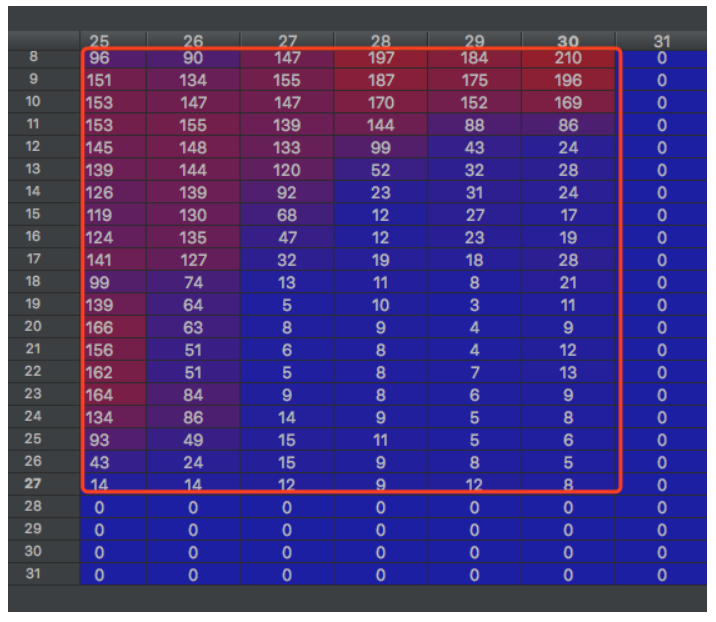

#### 3）Totensor

- 第二个处理是 transforms.ToTensor()

- 在这里会对数据进行 transpose，原来是 hxwxc，会经过 img = img.transpose(0, 1).transpose(0, 2).contiguous()，变成 cxhxw 再除以 255，使得像素值归一化至[0-1]之间，我们来看看 Red 通道。

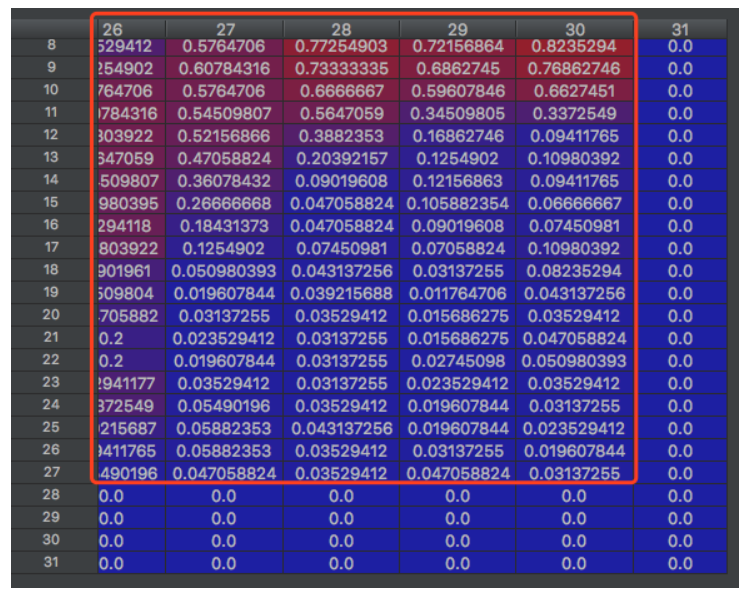

27 行，30 列 原来是 8 的， 经过 ToTensor 之后变成：8/255= 0.03137255

#### 4）数据标准化(减均值，除以标准差)

- 第三个处理是对图像进行标准化：transforms.Normalize

- 功能：逐channel的对图像进行标准化 output = (input - mean) / std

- 通过标准化之后，再来看看 Red 通道的数据：

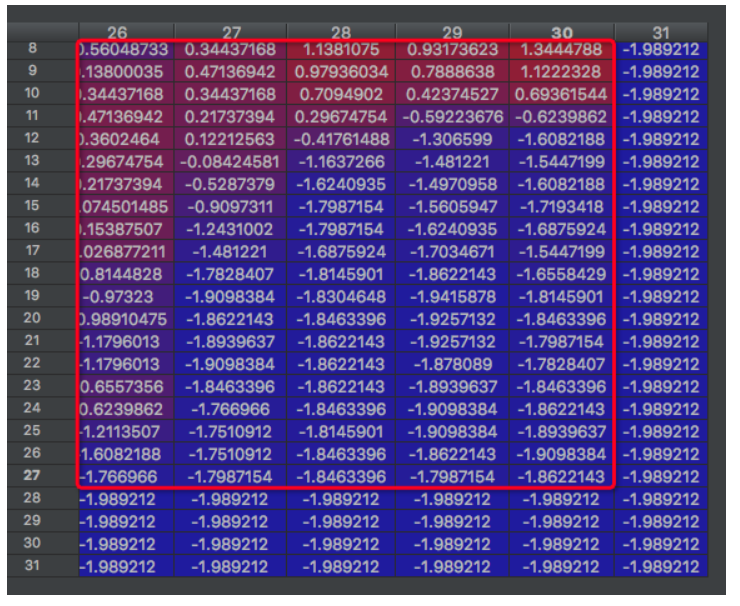

至此，数据预处理完毕，最后转换成 Variable 类型，就是输入网络模型的数据了。在进行 Normalize 时，需要设置均值和方差，在这里直接给出了，但在实际应用中是要去训练集中计算的，

#### 5）定义显示图像的函数

In [2]:
import matplotlib.pyplot as plt 
def showimg(transform,i=0):
    data = DogCatDataset(data_dir=train_dir, transform=transform)
    # 构建DataLoder
    loader = DataLoader(dataset=data, batch_size=1)
    for data in loader:
        if data[0].ndim==5:
            img=data[0][0][i].numpy()
        else:
            img=data[0][0].numpy()
        #print(img)
        #C H  W
        if img.shape[0]==3:
            img=img.transpose(1,2,0)# chw -->hwc
        if img.ndim==3:
            plt.imshow(img)
        else:
            plt.imshow(img,cmap='gray')
        plt.show()
        break

# 备用
# def showimg(transform):
#     data = DogCatDataset(data_dir=train_dir, transform=transform)
#     # 强制设置 num_workers=0，防止多进程冲突
#     loader = DataLoader(dataset=data, batch_size=1, num_workers=0)
    
#     for img_tensor, label in loader:
#         # 1. 检查数据维度 (Batch, C, H, W) -> (C, H, W)
#         img = img_tensor[0]
        
#         # 2. 如果是 Tensor (即加了 ToTensor)，将其转为符合 plt 要求的 numpy
#         if isinstance(img, torch.Tensor):
#             # 将 [C, H, W] 换位 [H, W, C]
#             img = img.permute(1, 2, 0).numpy()
#             # 此时 img 是 0-1 之间的浮点数，plt 可以正常处理
#         elif isinstance(img, np.ndarray):
#             # 已经是 ndarray 的情况
#             pass
#         else:
#             # 如果没加 ToTensor，img 可能是 PIL 对象，转为 ndarray
#             img = np.array(img)

#         plt.imshow(img)
#         plt.title(f"Label: {'Dog' if label == 1 else 'Cat'}")
#         plt.show()
#         break # 只看一张

### 6.2 裁剪Crop
#### 1）随机裁剪：transforms.RandomCrop

**torchvision.transforms.RandomCrop(size, padding=None, pad_if_needed=False, fill=0,padding_mode='constant')**

    - 功能：依据给定的 size 随机裁剪

**参数：**

- size： (sequence or int)，若为 sequence,则为(h,w)，若为 int，则(size,size)

- padding：(sequence or int, optional)，此参数是设置填充多少个 pixel。

    - 当为a时，上下左右均填充a个像素
    - 当为(a, b)时，上下填充b个像素，左右填充a个像素
    - 当为(a, b, c, d)时，左，上，右，下分别填充a, b, c, d

- fill： (int or tuple) 填充的值是什么（仅当填充模式为 constant 时有用）。int 时，各通道均填充该值，当长度为 3 的 tuple 时，表示 RGB 通道需要填充的值。

- padding_mode： 填充模式，这里供了 4 种填充模式：

    - 1、constant：像素值由fill设定
    - 2、edge：像素值由图像边缘像素决定
    - 3、reflect：镜像填充，最后一个像素不镜像，eg：[1,2,3,4] → [3,2,1,2,3,4,3,2]
    - 4、symmetric：镜像填充，最后一个像素镜像，eg：[1,2,3,4] → [2,1,1,2,3,4,4,3]

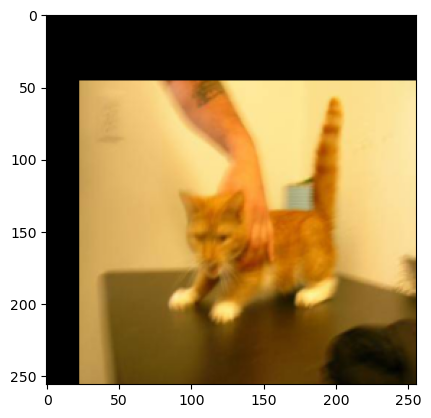

In [3]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(256, padding = 64),
    #transforms.ToTensor() #scripts中转array可以不用转tensor了
])

showimg(transform)

#### 2）中心裁剪：transforms.CenterCrop

torchvision.transforms.CenterCrop(size)

- 功能：依据给定的 size 从中心裁剪

参数：

- size- (sequence or int)，若为 sequence,则为(h,w)，若为 int，则(size,size)

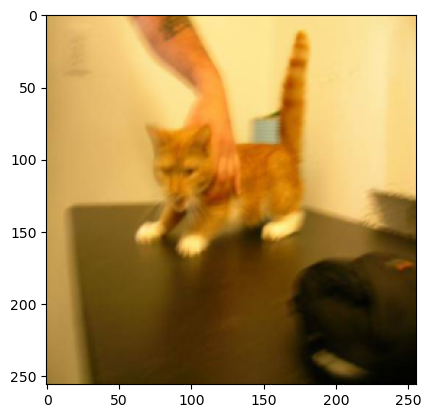

In [5]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(256),
])
showimg(transform)

#### 3）随机长宽比裁剪 transforms.RandomResizedCrop

torchvision.transforms.RandomResizedCrop(size, scale=(0.08, 1.0), ratio=(0.75, 1.3333333333333333), interpolation=2)

- 功能：随机大小，随机长宽比裁剪原始图片，最后将图片 resize 到设定好的 size

参数：

- size: 输出的分辨率
- scale: 随机 crop 的大小区间，如 scale=(0.08, 1.0)，表示随机 crop 出来的图片会在的 0.08倍至 1 倍之间。
- ratio: 随机长宽比设置
- interpolation: 插值的方法，默认为双线性插值(PIL.Image.BILINEAR)

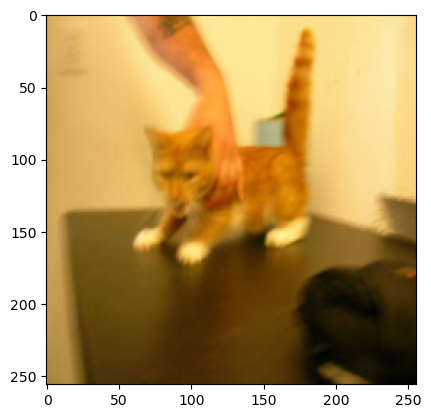

In [7]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(256, scale = (0.8, 1.0), ratio = (3/4, 4/3), interpolation = 2)
])

showimg(transform)

#### 4）上下左右中心裁剪：transforms.FiveCrop

torchvision.transforms.FiveCrop(size)

- 功能：对图片进行上下左右以及中心裁剪，获得 5 张图片，返回一个 4D-tensor

参数：

- size: (sequence or int)，若为 sequence,则为(h,w)，若为 int，则(size,size)

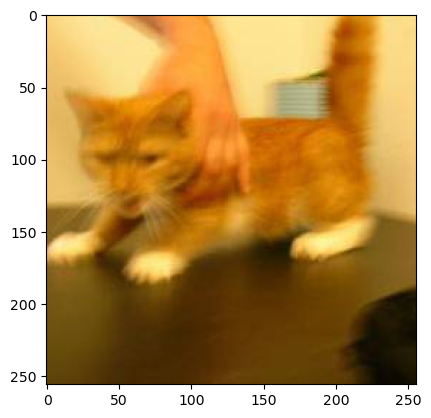

In [8]:
transform = transforms.Compose([
    #transforms.Resize((256, 256)),
    transforms.FiveCrop(256),
    transforms.Lambda(lambda crops: torch.stack([torch.tensor(np.array(crop), dtype = torch.int16) for crop in crops])), #将5d-tensor转换为4d
])

showimg(transform, 4)

#### 5）上下左右中心裁剪后翻转: transforms.TenCrop

torchvision.transforms.TenCrop(size, vertical_flip=False)

- 功能：对图片进行上下左右以及中心裁剪，然后全部翻转（水平或者垂直），获得 10 张图片，返回一个 4D-tensor。

参数：

- size： (sequence or int)，若为 sequence,则为(h,w)，若为 int，则(size,size)
- vertical_flip (bool) - 是否垂直翻转，默认为 flase，即默认为水平翻转

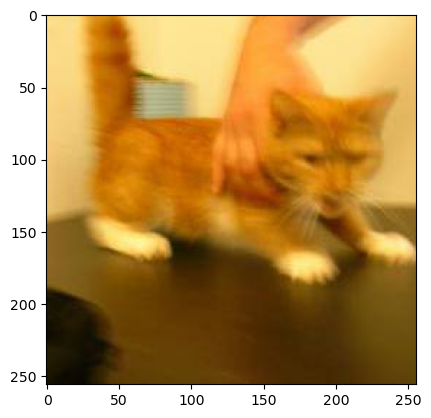

In [10]:
transform = transforms.Compose([
    transforms.TenCrop(256),
    transforms.Lambda(lambda crops: torch.stack([torch.tensor(np.array(crop), dtype = torch.int16) for crop in crops])) #将5d-tensor转换为4d
])

showimg(transform, 9)

### 6.3 翻转和旋转——Flip and Rotation
#### 1）依概率 p 水平翻转 transforms.RandomHorizontalFlip

torchvision.transforms.RandomHorizontalFlip(p=0.5)

- 功能：依据概率 p 对 PIL 图片进行水平翻转

参数：

- p： 概率，默认值为 0.5

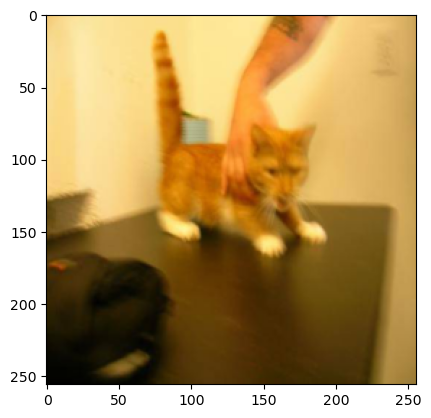

In [11]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip()
])

showimg(transform)

#### 2）依概率 p 垂直翻转 transforms.RandomVerticalFlip

torchvision.transforms.RandomVerticalFlip(p=0.5)

- 功能：依据概率 p 对 PIL 图片进行垂直翻转

参数:

- p： 概率，默认值为 0.5

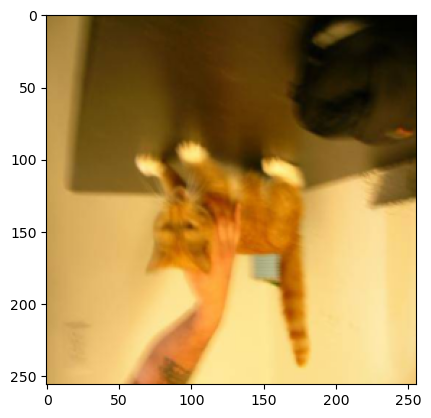

In [13]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomVerticalFlip()
])

showimg(transform)

#### 3）随机旋转：transforms.RandomRotation

torchvision.transforms.RandomRotation(degrees, resample=False, expand=False, center=None)

- 功能：依 degrees 随机旋转一定角度

参数：

- degrees：旋转角度
    - 当为a时，在（-a，a）之间选择旋转角度
    - 当为(a, b)时，在(a, b)之间选择旋转角度
- resample：重采样方法
- expand：是否扩大图片，以保持原图信息
- center：旋转点设置，默认中心旋转

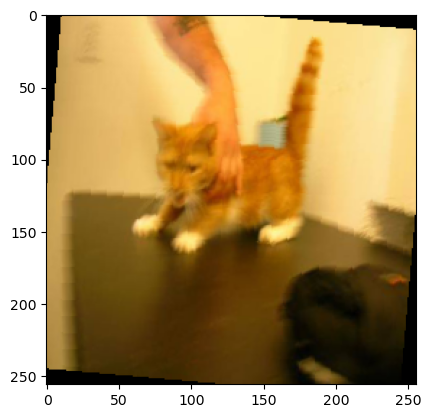

In [14]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomRotation(30)
])

showimg(transform)

### 6.4 图像变换
#### 1）填充：transforms.Pad

torchvision.transforms.Pad(padding, fill=0, padding_mode='constant')

- 功能：对图像进行填充

参数：

- padding：设置填充大小
    - 当为a时，上下左右均填充a个像素
    - 当为(a, b)时，上下填充b个像素，左右填充a个像素
    - 当为(a, b, c, d)时，左，上，右，下分别填充a, b, c, d
- padding_mode：填充模式，有4种模式，constant、edge、reflect和symmetric
- fill：constant时，设置填充的像素值，(R, G, B) or (Gray)

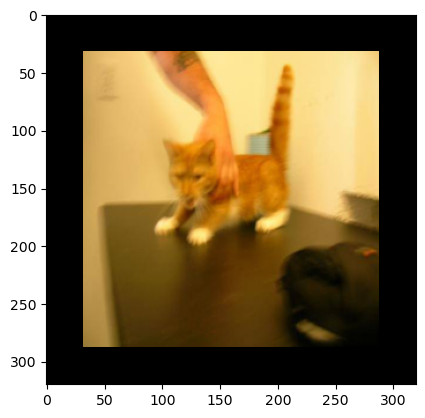

In [15]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.Pad(32)
])

showimg(transform)

#### 2）resize：transforms.Resize

torchvision.transforms.Resize(size, interpolation=2)

- 功能：重置图像分辨率

参数：

- size： If size is an int, if height > width, then image will be rescaled to (size * height / width, size)，所以建议 size 设定为 h*w
- interpolation： 插值方法选择，默认为 PIL.Image.BILINEAR

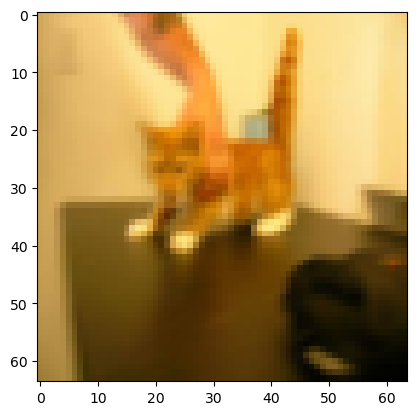

In [17]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
])

showimg(transform)

#### 3）修改亮度、对比度和饱和度：transforms.ColorJitter

torchvision.transforms.ColorJitter(brightness=0, contrast=0, saturation=0, hue=0)

- 功能：修改修改亮度、对比度和饱和度

参数：

- brightness：亮度调整因子
    - 当为a时，从[max(0, 1-a), 1+a]中随机选择
    - 当为(a, b)时，从[a, b]中
- contrast：对比度参数，同brightness
- saturation：饱和度参数，同brightness
- hue：色相参数
    - 当为a时，从[-a, a]中选择参数，注： 0<= a <= 0.5
    - 当为(a, b)时，从[a, b]中选择参数，注：-0.5 <= a <= b <= 0.5

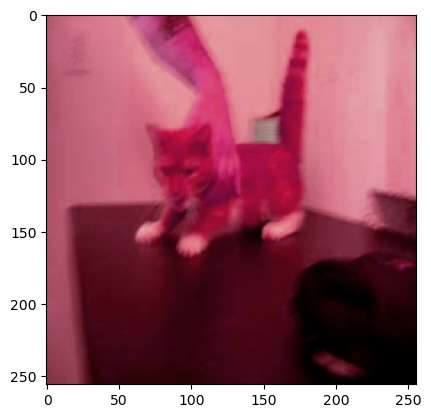

In [22]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ColorJitter(brightness = 0.1, contrast = 0.2, saturation = 0.3, hue = 0.2)
])

showimg(transform)

#### 4） 转灰度图：transforms.Grayscale

torchvision.transforms.Grayscale(num_output_channels=1)

- 功能：将图片转换为灰度图

参数：

- num_output_channels： (int) ，当为 1 时，正常的灰度图，当为 3 时， 3 channel with r == g == b

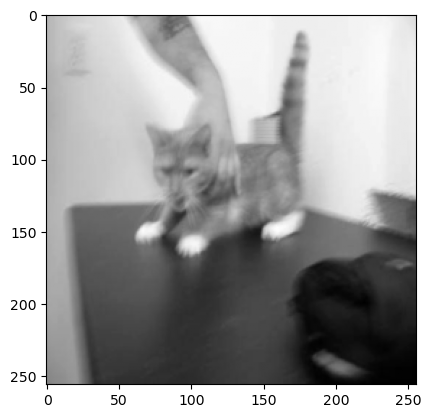

In [23]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.Grayscale(1)
])

showimg(transform)

#### 5）依概率 p 转为灰度图：transforms.RandomGrayscale

torchvision.transforms.RandomGrayscale(p=0.1)

- 功能：依概率将图片转换为灰度图

参数：

- num_ouput_channels：输出通道数只能设1或3
- p：概率值，图像被转换为灰度图的概率

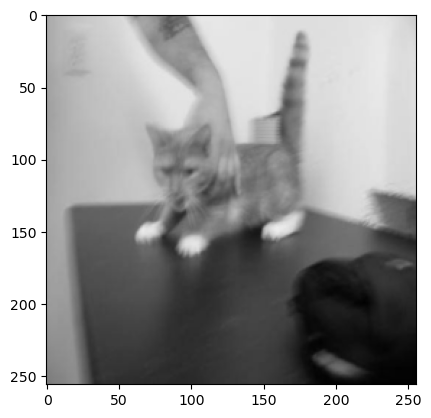

In [24]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomGrayscale(0.5)
])

showimg(transform)

#### 6）仿射变换：transforms.RandomAffine

torchvision.transforms.RandomAffine(degrees, translate=None, scale=None, shear=None, resample=False, fillcolor=0)

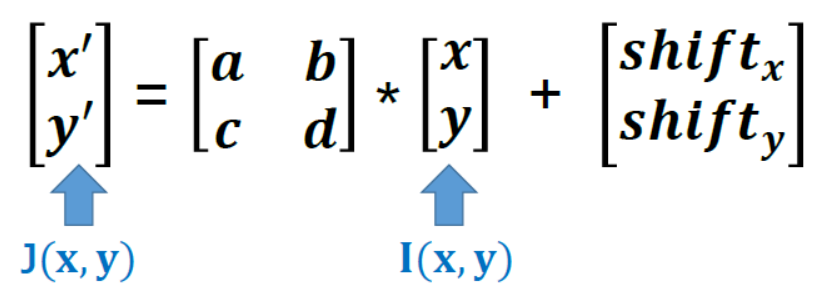

- 功能：对图像进行仿射变换，仿射变换是二维的线性变换，由五种基本原子变换构成，分别是旋转、平移、缩放、错切和翻转

参数：

- degrees：旋转角度设置
- translate：平移区间设置，如(a, b), a设置宽（width），b设置高(height)图像在宽维度平移的区间为 -img_width * a < dx < img_width * a
- scale：缩放比例（以面积为单位），长度为2的元组或者列表，值为0-1
- fill_color：填充颜色设置

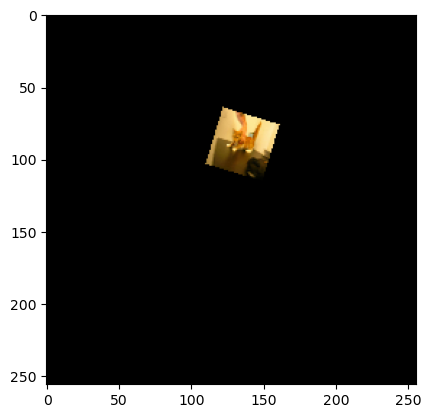

In [25]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomAffine(degrees = 30, translate = (0.1, 0.2), scale = (0.1, 0.2))
])

showimg(transform)

#### 7）transforms.RandomErasing

RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3), value=0, inplace=False)

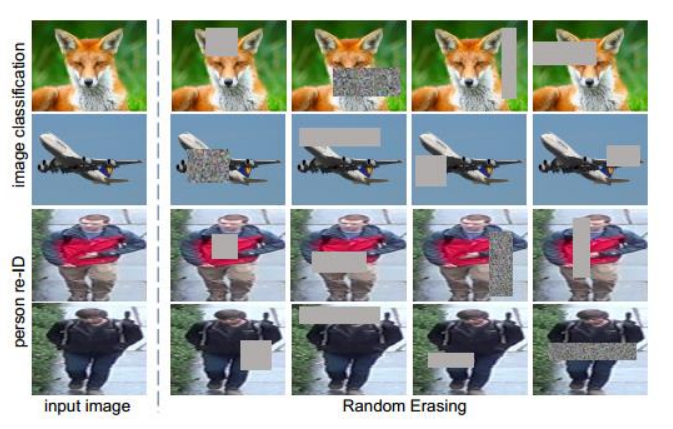

- 功能：对图像进行随机遮挡

参数：

- p：概率值，**执行该操作的概率**
- scale：遮挡区域的面积，长度为2的元组或者列表，值为0-1
- ratio：遮挡区域长宽比，长度为2的元组或者列表，值为0-1
- value：设置遮挡区域的像素值，(R, G, B) or (Gray)

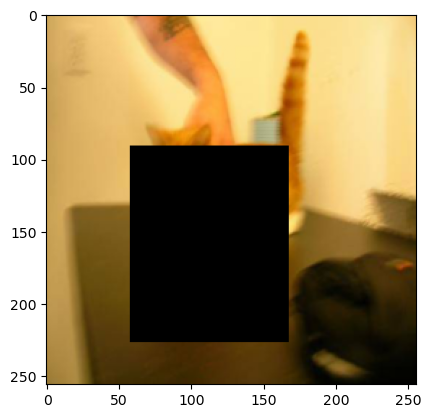

In [26]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.RandomErasing(p = 0.5, scale = (0.02, 0.33), ratio = (0.3, 3.3))
])

showimg(transform)

#### 8）transforms.Lambda

Lambda(lambd)

- 功能：用户自定义lambda方法

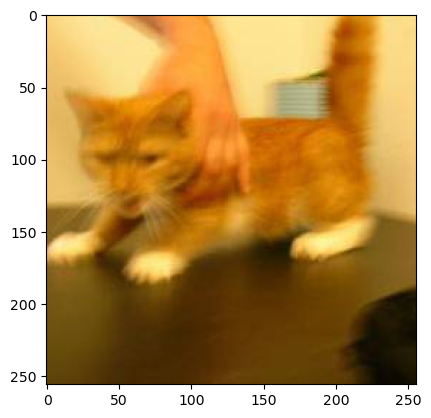

In [27]:
transform = transforms.Compose([
    #transforms.Resize((256, 256)),
    transforms.FiveCrop(256),
    transforms.Lambda(lambda crops: torch.stack([torch.tensor(np.array(crop), dtype = torch.int16) for crop in crops])), #将5d-tensor转换为4d
])

showimg(transform, 4)

### 6.5 对 transforms 操作，使数据增强更灵活

PyTorch 不仅可设置对图片的操作，还可以对这些操作进行随机选择、组合

#### 1）transforms.RandomChoice(transforms)

transforms.RandomChoice([transforms1, transforms2, transforms3])

- 功能：从给定的一系列 transforms 中选一个进行操作，randomly picked from a list

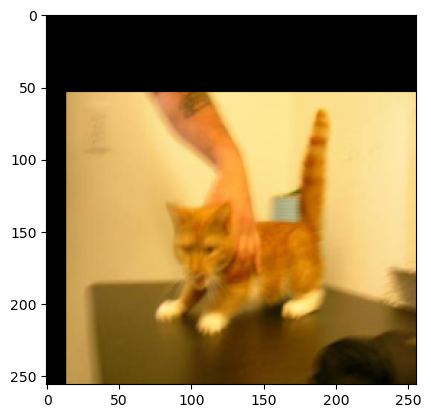

In [31]:
t1 = transforms.RandomCrop(256, padding = 64)
t2 = transforms.RandomHorizontalFlip()
t3 = transforms.ColorJitter(brightness = 0.1, contrast = 0.2, saturation = 0.3, hue = 0.2)

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomChoice([t1, t2, t3])
])

showimg(transform)

#### 2） transforms.RandomApply

transforms.RandomApply([transforms1, transforms2, transforms3], p=0.5)

- 功能：依据概率执行一组transforms操作(要么都执行，要么不执行)

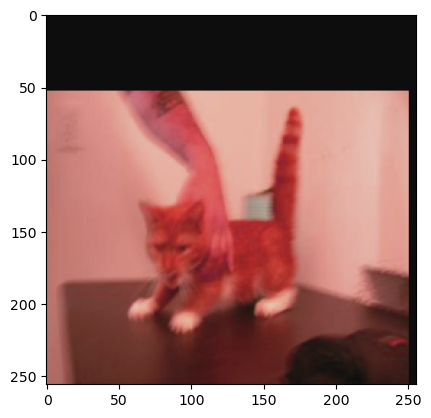

In [32]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomApply([t1, t2, t3], p = 0.5)
])

showimg(transform)

#### 3）transforms.RandomOrder

transforms.RandomOrder([transforms1, transforms2, transforms3])

- 功能：对一组transforms操作打乱顺序

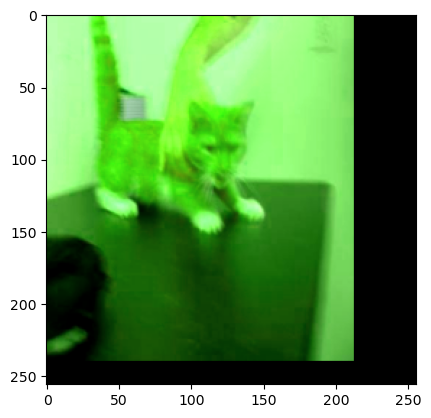

In [33]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomOrder([t1, t2, t3])
])

showimg(transform)

### 6.6 自定义transforms
#### 1）自定义transform的要求

自定义transforms要素：

    - 仅接收一个参数，返回一个参数
    - 注意上下游的输出与输入

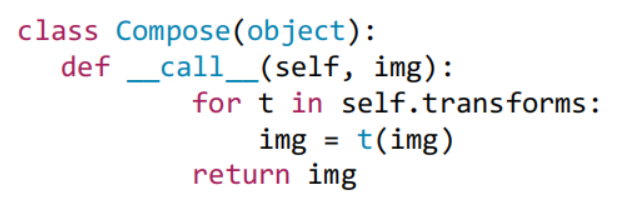

In [34]:
# class YourTransforms(object):
#     def __init__(self, ...):
#     ...
#     def __call__(self, img):
#     ...
#     return img

#### 2）自定义transform示例：一定概率添加椒盐噪声

**椒盐噪声**

- 椒盐噪声又称为脉冲噪声，是一种随机出现的白点或者黑点, 白点称为盐噪声，黑色为椒噪声

- 信噪比（Signal-Noise Rate, SNR）是衡量噪声的比例，图像中为图像像素的占比

In [ ]:
import random
from PIL import Image

class AddPepperNoise(object):
    def __init__(self, snr, p = 0.5):
        self.snr = snr
        self.p = p
    def __call__(self, img):
        if random.random() < self.p:
            img = self._sp_noise(img)
        return img
    
    def _sp_noise(self, img):
        '''
        添加椒盐噪声
        prob:信噪比（self.snr是类的属性，0-1之间，值越高噪声越少）
        '''
        output = np.array(img)
        h, w, _ = output.shape
        sp = h * w # 计算图像像素点个数
        NP = int(sp * (1 - self.snr)) # 计算图像椒盐噪声点个数
        randx = np.random.randint(1, h - 1, NP) # 生成NP个 1 至 h-1 之间的随机整数
        randy = np.random.randint(1, w - 1, NP) # 生成一个 1 至 w-1 之间的随机整数
        p = np.random.random(NP) # 生成NP个 0 至 1 之间的浮点数
        output[randx, randy] = np.where(p <= 0.5, 0, 255).reshape(-1, 1)
        return Image.fromarray(np.uint8(output))

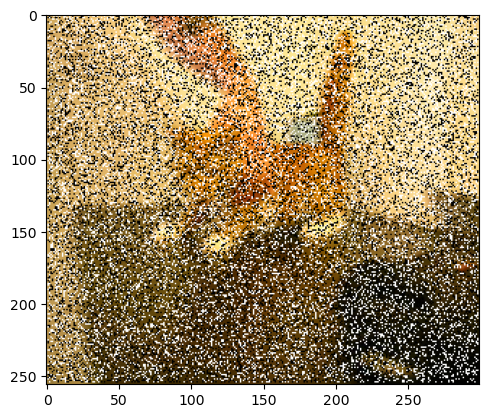

In [41]:
transform = transforms.Compose([
    transforms.Resize((256, 300)),
    AddPepperNoise(snr = 0.5, p = 1)
])

showimg(transform)